# Week 21: Autonomous prediction: representation, phase and dynamics

After removing the POD floor, what advantage remains over a four-frame MLP and DMD?

**Prerequisites:** Week 7 modal forecasting, Week 18 all-position causal learning; no reset at the evaluation boundary.

Allow 120 minutes plus the written analysis. Student edition: worked examples run immediately; set RUN_EXERCISES=True after completing the four functions. Incomplete tasks are reported, never counted as passes.

In [1]:
from pathlib import Path
import sys, tempfile, json
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'flowmllab/transformer_course.py').exists()),None)
if ROOT is None:
    raise RuntimeError('Extract the supplied course bundle and start Jupyter in its root; see docs/TRANSFORMER_COURSE.md for Colab upload setup.')
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from flowmllab import transformer_course as lab
lab.seed_all(17)
cases,input_manifest=lab.load_data(ROOT)
EVIDENCE=ROOT/'results/transformer_course_v3'
# Any optional experiment must write into this disposable workspace.
workspace=tempfile.TemporaryDirectory(prefix='flowmllab-student-')
RUN_OUTPUT=Path(workspace.name)
task_status={}
print('Loaded checksummed simulated wake fields. No retained files will be rewritten.')

task_status={i:None for i in range(1,5)}


Loaded checksummed simulated wake fields. No retained files will be rewritten.


In [2]:
RUN_EXERCISES=False

## Rescore full trajectories and compare matched-information models

The primary trajectory starts at frame 160 from frames 156:160. The evaluation boundary at 210 is not an assimilation event. Additional-start metrics in the record are a separate observed-initialization protocol.

,model,seed,field_relative_l2,representation_floor,in_subspace_relative_l2,pythagorean_residual
0,Causal-Transformer,17.0,0.054915,0.054519,6.588947e-03,8.944668e-19
1,History-MLP,17.0,0.055287,0.054519,9.185769e-03,6.098637e-19
2,Causal-Transformer,29.0,0.054874,0.054519,6.234160e-03,5.421011e-19
3,History-MLP,29.0,0.054886,0.054519,6.338854e-03,1.409463e-18
4,Causal-Transformer,43.0,0.055864,0.054519,1.218767e-02,-4.119968e-18
5,History-MLP,43.0,0.055157,0.054519,8.368061e-03,-1.490778e-19
6,DMD-r8,NaN,0.064368,0.054519,3.421877e-02,-4.987330e-18
7,Persistence,NaN,1.131266,0.054519,1.129956e+00,-1.063988e-05
8,POD-oracle,NaN,0.054519,0.054519,1.037060e-15,-1.075493e-30


Earlier Week 7 MLP reference: {'relative_l2': 0.05537, 'source': 'results/modal_labs/metrics.json', 'status': 'Published Week 7 reference; use the new matched History-MLP for direct comparisons.'}


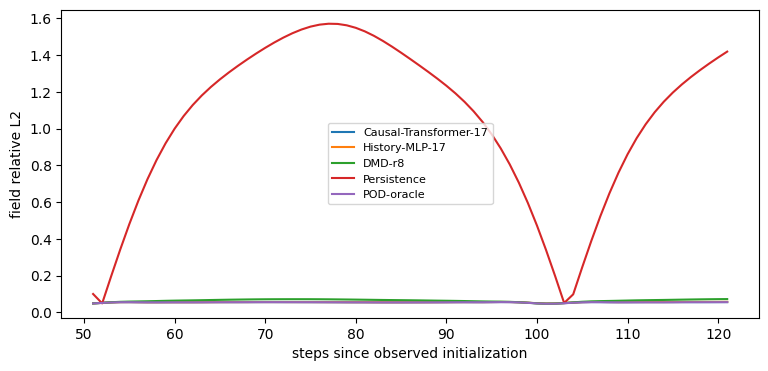

In [3]:
record=json.loads((EVIDENCE/'forecast.json').read_text());display(pd.DataFrame([{'model':r['method'],'seed':r['seed'],**{k:v for k,v in r['metrics'].items() if k!='per_frame_relative_l2'}} for r in record['rows']]))
print('Earlier Week 7 MLP reference:',record['legacy_MLP_reference'])
retained=np.load(EVIDENCE/'predictions.npz',allow_pickle=False)
truth=cases[110]['omega'][210:].reshape(71,-1)
fig,ax=plt.subplots(figsize=(9,4))
for row in record['rows']:
    if row['seed'] in (None,17):
        pred=lab.prediction(retained,'forecast__'+row['key'])[50:]
        curve=np.linalg.norm(pred-truth,axis=1)/np.linalg.norm(truth,axis=1)
        ax.plot(np.arange(51,122),curve,label=row['key'])
ax.set_xlabel('steps since observed initialization');ax.set_ylabel('field relative L2');ax.legend(fontsize=8);plt.show()

## Phase and amplitude from the full rollout

A 71-frame FFT cannot resolve small frequency differences. Fit frequency, amplitude and phase over the 121-frame rollout instead. This remains a local scalar probe, not lift or drag; the fit residual checks whether the sinusoidal model is plausible. Initial phase is defined at the first sample of the rollout, using t-t[0]. Constant signals have no identifiable frequency or phase.

In [4]:
display(pd.DataFrame(record['spectral_fit']).T)
reference=record['spectral_fit']['reference']
print('Observation duration:',reference['duration'],'D/U; sinusoidal-fit residual:',reference['residual_mse'])
rep=lab.Representation.fit(cases[110]['omega'][:160],8)
row=next(r for r in record['rows'] if r['method']=='Causal-Transformer')
pred=lab.prediction(retained,'forecast__'+row['key'])[50:]
parts=lab.error_components(pred,truth,rep)
assert abs(parts['pythagorean_residual'])<1e-8
print('Squared-error decomposition residual:',parts['pythagorean_residual'])

,frequency,amplitude,phase,residual_mse,r_squared,duration,frequency_relative_error,initial_phase_error,phase_drift_over_horizon
reference,0.184999,1.207091,-1.261280,0.298148,0.698333,12.5,NaN,NaN,NaN
Causal-Transformer-17,0.185026,1.202354,-1.259898,0.291010,0.701759,12.5,0.000149,0.001382,0.002168
History-MLP-17,0.184788,1.203481,-1.258778,0.291775,0.701563,12.5,0.001137,0.002502,-0.016520
Causal-Transformer-29,0.185028,1.205788,-1.259462,0.291879,0.702324,12.5,0.000156,0.001818,0.002270
History-MLP-29,0.184909,1.204822,-1.259018,0.291959,0.701913,12.5,0.000486,0.002261,-0.007063
Causal-Transformer-43,0.185091,1.202519,-1.261783,0.289685,0.702799,12.5,0.000498,-0.000503,0.007239
History-MLP-43,0.184808,1.203664,-1.259132,0.291413,0.701893,12.5,0.001031,0.002147,-0.014978
DMD-r8,0.184753,1.171045,-1.251434,0.276839,0.701040,12.5,0.001329,0.009846,-0.019306
Persistence,NaN,0.000000,NaN,0.000000,NaN,12.5,NaN,NaN,NaN
POD-oracle,0.184939,1.205354,-1.258264,0.291812,0.702198,12.5,0.000321,0.003016,-0.004663


Observation duration: 12.5 D/U; sinusoidal-fit residual: 0.29814788453880753
Squared-error decomposition residual: 8.944667923005412e-19


## Task 1: Autonomous state update

Roll a history window forward by dropping its oldest token and appending the prediction. Do not read a future observed state.

Interface contract: history:[context,features] and next_state:[features] are NumPy arrays. Return a new [context,features] array in chronological order without changing the inputs.

In [5]:
def advance(history,next_state):
    """history:[context,features] and next_state:[features] are NumPy arrays. Return a new [context,features] array in chronological order without changing the inputs."""
    raise NotImplementedError

In [6]:
if RUN_EXERCISES:
    try:
        for context,width in ((4,8),(2,3)):
            h=np.arange(context*width).reshape(context,width)*3+7
            n=np.arange(width)*-2-3
            result=advance(h,n)
            np.testing.assert_array_equal(result[:-1],h[1:])
            np.testing.assert_array_equal(result[-1],n)
            assert result.shape==h.shape
        task_status[1]=True
    except NotImplementedError:
        task_status[1]=None
    except Exception as exc:
        task_status[1]=False
        print("Task 1 check failed:",type(exc).__name__,str(exc))
else:
    task_status[1]=None
print("Task 1:","PASS" if task_status[1] is True else "NOT SUBMITTED" if task_status[1] is None else "FAILED")

Task 1: NOT SUBMITTED


## Task 2: Separate representation and dynamics

Compute the squared total error, representation error and in-subspace error for an orthogonal projector.

Interface contract: pred,truth,oracle have identical shapes; truth is nonzero, oracle is an orthogonal affine projection and pred is in that affine span. Return a tuple of three scalar squared relative errors (total,floor,dynamic), each divided by sum(truth**2).

In [7]:
def decompose(pred,truth,oracle):
    """pred,truth,oracle have identical shapes; truth is nonzero, oracle is an orthogonal affine projection and pred is in that affine span. Return a tuple of three scalar squared relative errors (total,floor,dynamic), each divided by sum(truth**2)."""
    raise NotImplementedError

In [8]:
if RUN_EXERCISES:
    try:
        for y,projection,prediction in [(np.array([[1.,2.,3.]]),np.array([[1.,2.,0.]]),np.array([[2.,1.,0.]])),(np.array([[2.,1.,1.]]),np.array([[2.,1.,0.]]),np.array([[2.,3.,0.]]))]:
            total,floor,dynamic=decompose(prediction,y,projection)
            expected=[np.sum((prediction-y)**2)/np.sum(y*y),np.sum((projection-y)**2)/np.sum(y*y),np.sum((prediction-projection)**2)/np.sum(y*y)]
            np.testing.assert_allclose([total,floor,dynamic],expected)
            assert abs(total-floor-dynamic)<1e-12
        task_status[2]=True
    except NotImplementedError:
        task_status[2]=None
    except Exception as exc:
        task_status[2]=False
        print("Task 2 check failed:",type(exc).__name__,str(exc))
else:
    task_status[2]=None
print("Task 2:","PASS" if task_status[2] is True else "NOT SUBMITTED" if task_status[2] is None else "FAILED")

Task 2: NOT SUBMITTED


## Task 3: Frequency-fit diagnostic

Measure relative frequency error using the continuous fitted frequency, not the closest FFT bin.

Interface contract: t,y are one-dimensional equal-length NumPy arrays, and fref>0. Return a scalar abs(fitted_frequency/fref-1), using lab.spectral_fit. Only an oscillatory signal with an identifiable fit is supplied.

In [9]:
def frequency_error(t,y,fref):
    """t,y are one-dimensional equal-length NumPy arrays, and fref>0. Return a scalar abs(fitted_frequency/fref-1), using lab.spectral_fit. Only an oscillatory signal with an identifiable fit is supplied."""
    raise NotImplementedError

In [10]:
if RUN_EXERCISES:
    try:
        t=np.arange(121)*.1041667+79.17
        for f,fref in ((.18537,.17),(.19321,.21)):
            assert np.isclose(frequency_error(t,np.sin(2*np.pi*f*(t-t[0])+.3),fref),abs(f/fref-1),atol=1e-4)
        task_status[3]=True
    except NotImplementedError:
        task_status[3]=None
    except Exception as exc:
        task_status[3]=False
        print("Task 3 check failed:",type(exc).__name__,str(exc))
else:
    task_status[3]=None
print("Task 3:","PASS" if task_status[3] is True else "NOT SUBMITTED" if task_status[3] is None else "FAILED")

Task 3: NOT SUBMITTED


## Task 4: Implement an autonomous rollout audit

Roll a history forward using only a supplied next-state function. Return predictions, per-step relative errors and one global relative error. Truth is used only after generating the trajectory. Validate dimensions and reject zero reference norms. Compare a stable and unstable predictor, then repeat from a different observed initialization without resetting at the evaluation boundary.

Interface contract: predict_next accepts a copy of history:[context,features] and returns one [features] vector. truth:[steps,features] sets the horizon and is used only for scoring after prediction. Return dictionary predictions ([steps,features] array), per_step_error (length-steps array), field_error (float GLOBAL Frobenius relative L2, not the mean of per-step ratios). Invalid dimensions/state width, nonfinite predictions or any zero per-step truth norm must raise ValueError.

In [11]:
def rollout_audit(predict_next,history,truth):
    """predict_next accepts a copy of history:[context,features] and returns one [features] vector. truth:[steps,features] sets the horizon and is used only for scoring after prediction. Return dictionary predictions ([steps,features] array), per_step_error (length-steps array), field_error (float GLOBAL Frobenius relative L2, not the mean of per-step ratios). Invalid dimensions/state width, nonfinite predictions or any zero per-step truth norm must raise ValueError."""
    raise NotImplementedError

In [12]:
if RUN_EXERCISES:
    try:
        for context in (2,4):
            h=np.ones((context,2));truth=np.ones((6,2))
            for factor in (1.,1.1):
                r=rollout_audit(lambda window:window[-1]*factor,h,truth)
                expected=np.repeat((factor**np.arange(1,7))[:,None],2,axis=1)
                np.testing.assert_allclose(r['predictions'],expected)
                np.testing.assert_allclose(r['per_step_error'],abs(factor**np.arange(1,7)-1))
            changed=rollout_audit(lambda window:window[-1]*1.1,h,truth*20)
            np.testing.assert_allclose(changed['predictions'],r['predictions'])
        try:
            rollout_audit(lambda window:np.zeros(3),h,truth)
            raise AssertionError('wrong state width accepted')
        except ValueError:pass
        truth=np.array([[1.,2.],[20.,4.],[.2,.1],[5.,8.]])
        h=np.ones((3,2))
        r=rollout_audit(lambda window:window[-1]*1.2,h,truth)
        expected_global=np.linalg.norm(r['predictions']-truth)/np.linalg.norm(truth)
        assert not np.isclose(expected_global,np.mean(r['per_step_error']))
        assert np.isclose(r['field_error'],expected_global)
        try:
            rollout_audit(lambda window:window[-1],h,np.zeros((3,2)))
            raise AssertionError('zero reference norm accepted')
        except ValueError:pass
        task_status[4]=True
    except NotImplementedError:
        task_status[4]=None
    except Exception as exc:
        task_status[4]=False
        print("Task 4 check failed:",type(exc).__name__,str(exc))
else:
    task_status[4]=None
print("Task 4:","PASS" if task_status[4] is True else "NOT SUBMITTED" if task_status[4] is None else "FAILED")

Task 4: NOT SUBMITTED


## Interpretation and submission

Submit the four completed functions, the requested plots/tables, and a 300-word claim ledger. Distinguish observations, fitted quantities, independent evaluation and unsupported extrapolation. Retain failed seeds. Use the lecture source for the rubric and assumptions.

In [13]:
print("Coding tasks passed:",sum(v is True for v in task_status.values()),"/",len(task_status))
workspace.cleanup()

Coding tasks passed: 0 / 4
